In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Analysing Data

In [4]:
test_data=pd.read_csv('/content/drive/MyDrive/Kaggle Playground/test.csv')

In [5]:
test_data

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25


In [8]:
sample_subission_data=pd.read_csv('/content/drive/MyDrive/Kaggle Playground/sample_submission.csv')
sample_subission_data

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


In [9]:
train_data = pd.read_csv('/content/drive/MyDrive/Kaggle Playground/train.csv')
train_data

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [10]:
train_data.isnull().sum()

,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
train_data.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
train_data['PhoneService'].value_counts()

,count
PhoneService,
Yes,557893
No,36301


In [14]:
yes_no_columns=['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling']
for i in yes_no_columns:
  print(train_data[i].value_counts())
  print('\n')

Partner
Yes    309554
No     284640
Name: count, dtype: int64


Dependents
No     414362
Yes    179832
Name: count, dtype: int64


PhoneService
Yes    557893
No      36301
Name: count, dtype: int64


MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64


OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64


OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64


DeviceProtection
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64


TechSupport
No                     288571
Yes                    164896
No internet service    140727
Name: count, dtype: int64


StreamingTV
Yes                    240301
No                     213166
No internet service    140727
Name: count, dtype: int64


StreamingMovies
Ye

In [15]:
train_data.replace('No internet service', 'No', inplace=True)
train_data.replace('No phone service', 'No', inplace=True)

# Convert 'Yes'/'No' to 1/0 for relevant columns
for col in yes_no_columns:
    train_data[col] = train_data[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Convert 'gender' to numerical
train_data['gender'] = train_data['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Convert 'Churn' to numerical (target variable)
train_data['Churn'] = train_data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,29,1,0,DSL,1,...,1,1,0,0,One year,1,Mailed check,60.10,1653.85,0
1,1,1,0,1,1,58,1,0,DSL,1,...,0,1,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0
2,2,1,0,1,0,58,1,1,Fiber optic,0,...,0,0,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0
3,3,0,0,0,0,1,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,69.70,70.70,1
4,4,0,0,0,0,1,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.45,70.45,1


Now, let's apply one-hot encoding to the remaining categorical columns: `InternetService`, `Contract`, and `PaymentMethod`.

In [16]:
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
train_data = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)
display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,False,False,True,False,False,False,True
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,False,False,False,True,True,False,False
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,True,False,False,False,False,True,False
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,True,False,False,False,False,True,False
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,True,False,False,False,False,True,False


Finally, let's also ensure `TotalCharges` is a numeric type. It often gets loaded as an object type due to empty strings or other non-numeric values. We'll convert it to numeric, coercing errors to NaN, and then fill any NaNs with 0 (or another appropriate strategy if needed).

In [18]:
train_data['TotalCharges'] = pd.to_numeric(train_data['TotalCharges'], errors='coerce')
train_data['TotalCharges'].fillna(0, inplace=True)
display(train_data)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,False,False,True,False,False,False,True
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,False,False,False,True,True,False,False
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,True,False,False,False,False,True,False
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,True,False,False,False,False,True,False
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,1,0,0,0,57,1,1,0,0,...,97.55,5460.70,0,True,False,False,True,False,False,False
594190,594190,0,0,0,0,72,1,1,1,1,...,91.95,6782.15,0,False,False,False,True,False,False,False
594191,594191,0,0,1,0,72,1,1,0,0,...,24.40,1871.90,0,False,True,False,True,True,False,False
594192,594192,0,0,0,0,32,1,1,0,0,...,86.00,2847.20,0,True,False,False,False,False,True,False


In [19]:
bool_cols = train_data.select_dtypes(include='bool').columns
train_data[bool_cols] = train_data[bool_cols].astype(int)

display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


<Axes: >

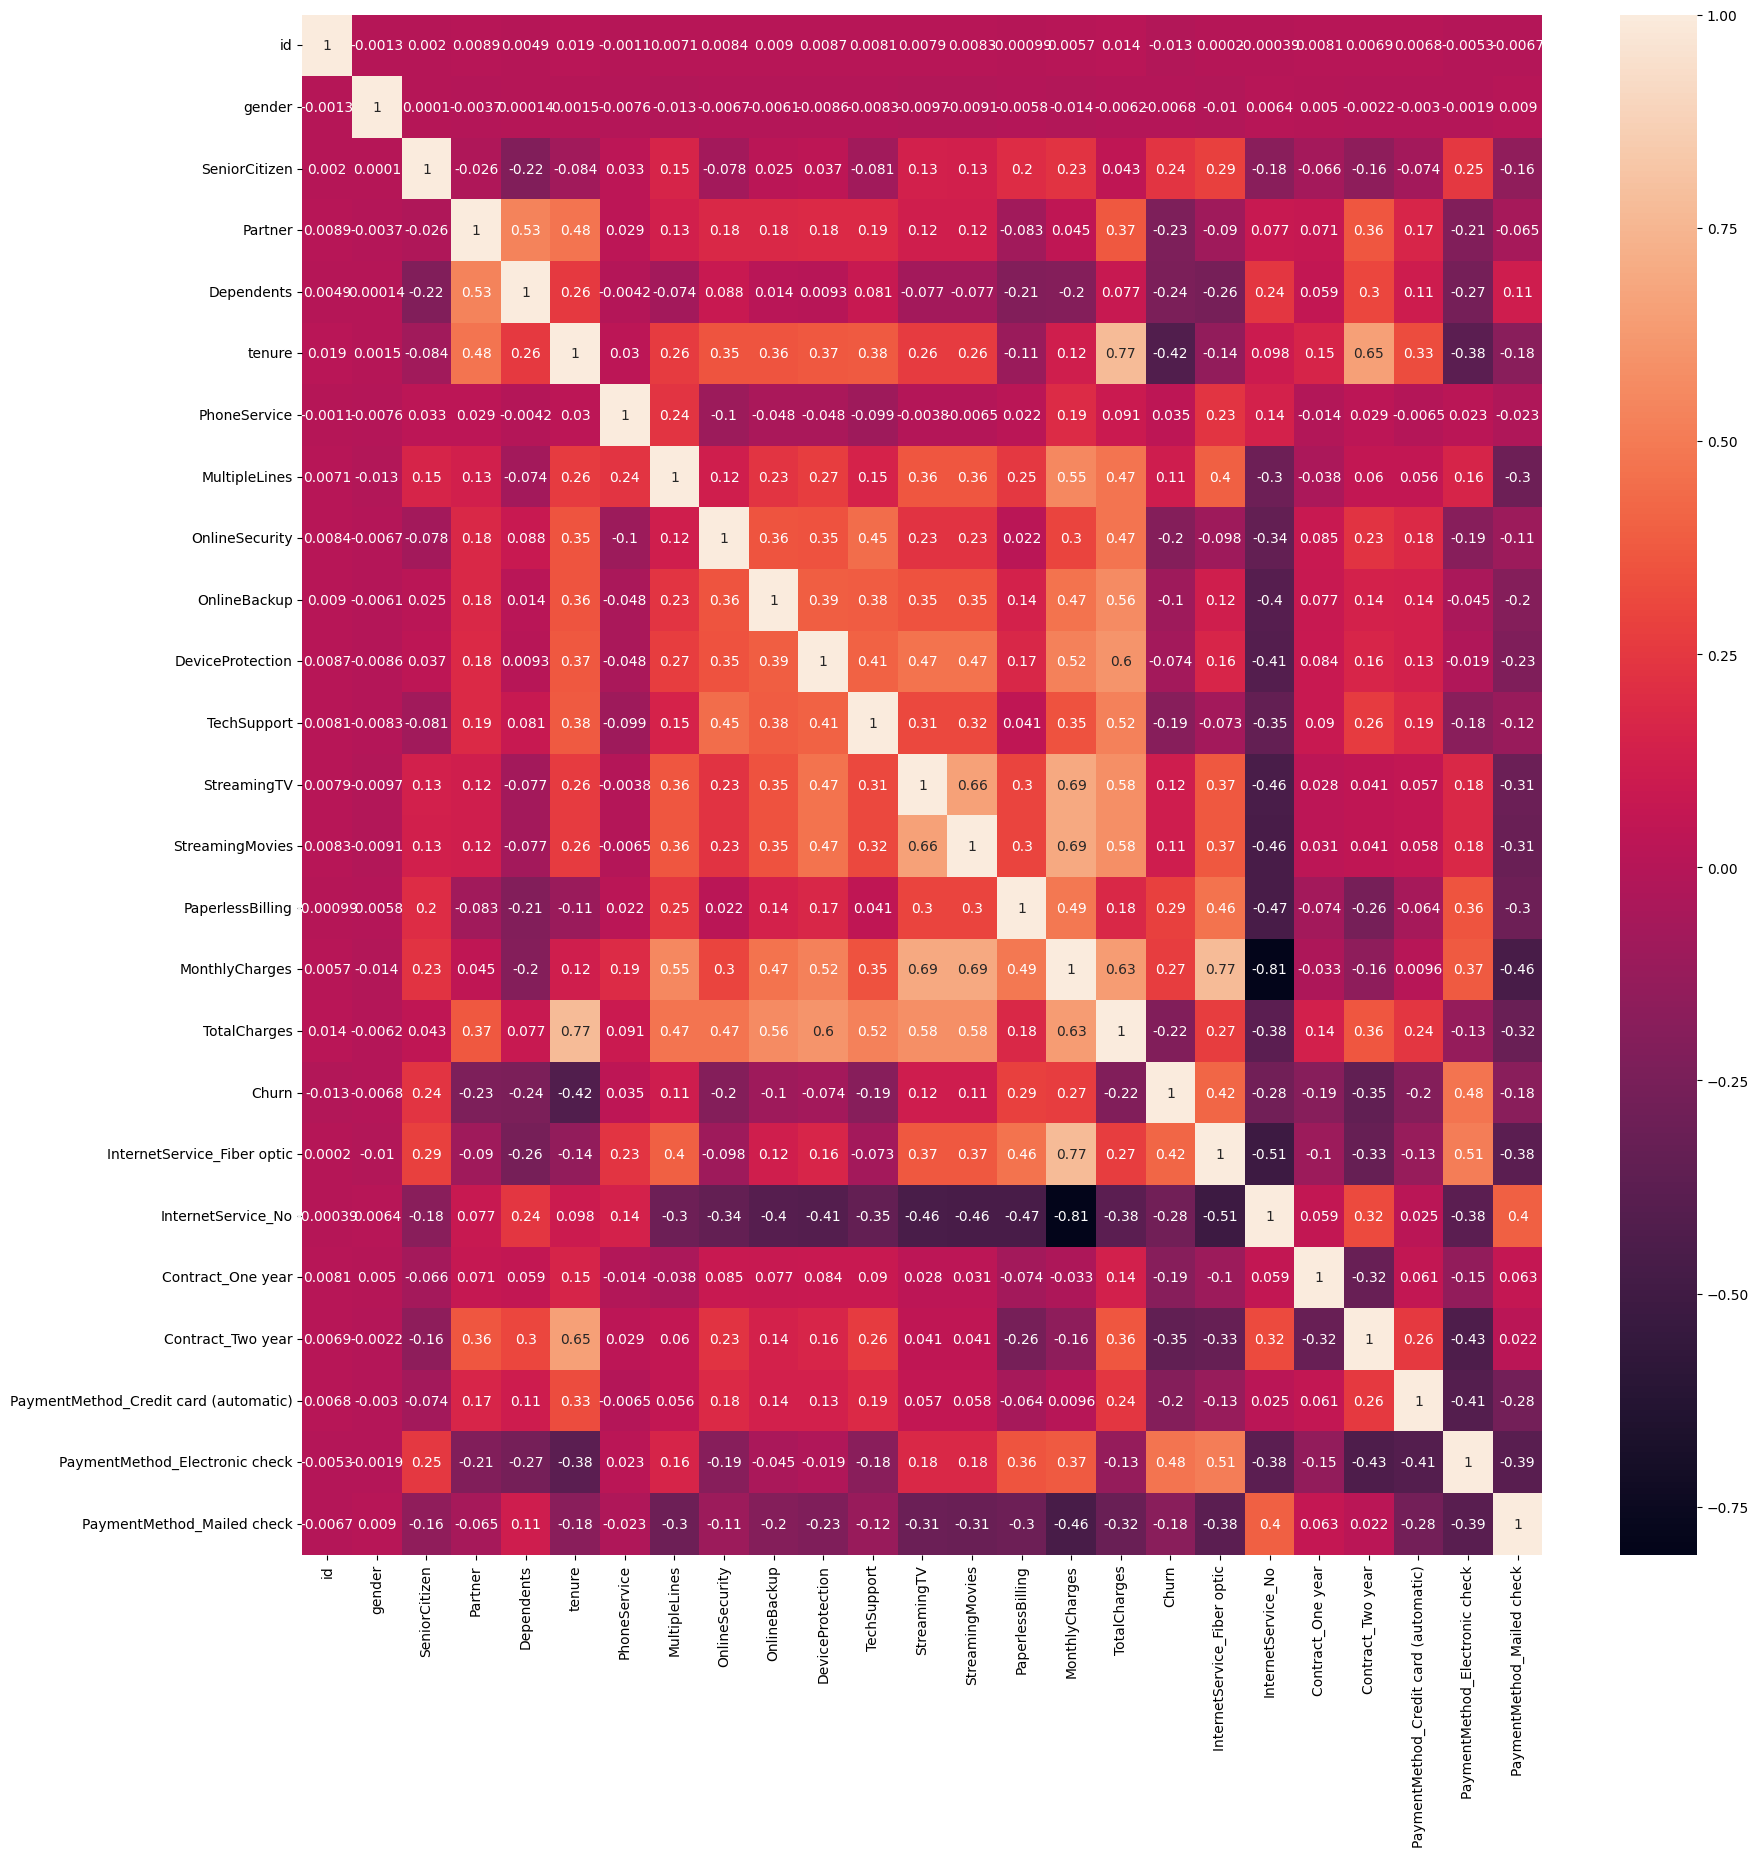

In [24]:
corr=train_data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True)

In [26]:
# Final check of data types and missing values
print("--- Data Types Summary ---")
print(train_data.dtypes.value_counts())

print("\n--- Columns with Non-Numeric Data ---")
print(train_data.select_dtypes(exclude=['number']).columns.tolist())

print("\n--- Missing Values Check ---")
print(train_data.isnull().sum().sum())

print("\n--- Dataset Shape ---")
print(train_data.shape)

display(train_data.head())

--- Data Types Summary ---
int64      23
float64     2
Name: count, dtype: int64

--- Columns with Non-Numeric Data ---
[]

--- Missing Values Check ---
0

--- Dataset Shape ---
(594194, 25)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


In [29]:
train_data['Churn'].value_counts()

,count
Churn,
0,460377
1,133817


In [30]:
train_data.to_csv("clean_train_data.csv", index=False)

In [34]:
clean_df=pd.read_csv('/content/clean_train_data.csv')
clean_df.describe()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,...,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.497238,0.114102,0.520965,0.302649,36.577258,0.938907,0.461985,0.275992,0.342286,...,65.866223,2494.377057,0.225208,0.458413,0.236837,0.182319,0.314616,0.225019,0.362461,0.208277
std,171529.177262,0.499993,0.317936,0.499561,0.459405,25.061922,0.239501,0.498553,0.447013,0.474475,...,31.067444,2353.916710,0.417719,0.498268,0.425142,0.386108,0.464363,0.417595,0.480711,0.406076
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,148548.250000,0.000000,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,0.000000,0.000000,...,29.900000,639.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,297096.500000,0.000000,0.000000,1.000000,0.000000,35.000000,1.000000,0.000000,0.000000,0.000000,...,74.100000,1433.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,445644.750000,1.000000,0.000000,1.000000,1.000000,62.000000,1.000000,1.000000,1.000000,1.000000,...,90.800000,4263.800000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,594193.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,...,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Analysis from Describe

